# NOURA EL KHOLTI

# K-Nearest Neighbors (KNN)
KNN (k-plus proches voisins) est un algorithme d’apprentissage supervisé qui classe ou prédit la valeur d’un point en fonction des k points les plus proches dans l’espace des données.

## Implémentation de l’algorithme KNN (K-plus proches voisins)

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# Calcul de la distance euclidienne entre deux points
def distance_euclidienne(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

# Prédire la classe d'un seul échantillon
def knn_predict_single(X_train, y_train, x, k):
    distances = []

    # Calculer la distance entre le point x et tous les points d'entraînement
    for i in range(len(X_train)):
        dist = distance_euclidienne(X_train[i], x)
        distances.append((dist, y_train[i]))

    # Trier les distances par ordre croissant (du plus proche au plus éloigné)
    distances.sort(key=lambda x: x[0])

    # Récupérer les k labels les plus proches
    k_labels = [label for (_, label) in distances[:k]]

    # Vote majoritaire pour déterminer la classe finale
    values, counts = np.unique(k_labels, return_counts=True)
    return values[np.argmax(counts)]

# Prédire les classes pour plusieurs échantillons
def knn_predict(X_train, y_train, X_test, k):
    predictions = []

    # Appliquer KNN à chaque point de test
    for x in X_test:
        pred = knn_predict_single(X_train, y_train, x, k)
        predictions.append(pred)
    
    return np.array(predictions)

## Données d’entraînement et de test

In [2]:
# Données d'entraînement (features)
X_train = np.array([
    [ 1,  5],
    [ 2,  2],
    [ 3,  4],
    [ 4,  6],
    [ 5,  3],

    [ 6, 11],
    [ 7, 14],
    [ 8, 12],
    [ 9, 10],
    [10, 13],

    [11,  3],
    [12,  6],
    [13,  4],
    [14,  2],
    [15,  5]
])

# Labels associés aux données d'entraînement (classes 0, 1, 2)
y_train = np.array([
    0, 0, 0, 0, 0,
    1, 1, 1, 1, 1,
    2, 2, 2, 2, 2
])

# Données de test (points à prédire)
X_test  = np.array([
    [ 6, 5],
    [ 8, 8],
    [10, 5]
])

## Prédiction et visualisation des résultats KNN

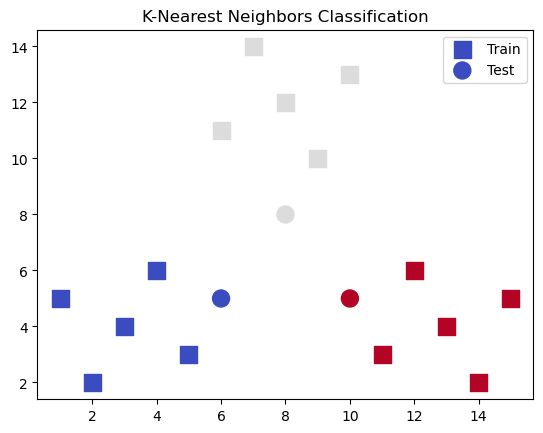

In [4]:
# Prédiction des classes pour les données de test
predictions = knn_predict(X_train, y_train, X_test, k=3)

# Affichage des résultats de prédiction
# print("Predictions:", predictions)

# Afficher les données d'entraînement
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', marker='s', s=150, label="Train")

# Afficher les données de test avec leurs prédictions
plt.scatter(X_test[:, 0], X_test[:, 1], c=predictions, cmap='coolwarm', marker='o', s=150, label="Test")

plt.legend()
plt.title("K-Nearest Neighbors Classification")

# Affichage du graphique
plt.show()